# Notebook 03 — Model Development

## Central Question

**Logistic regression is the regulatory default for PD modeling under SR 11-7 and IFRS 9. How do we tune it to extract maximum performance, and what performance gap are we accepting versus a gradient-boosted challenger?**

## Why It Matters

The model development stage is the heart of the SR 11-7 conceptual soundness story. Three audiences will read this notebook:

- **Model validators (second line of defense)** want evidence that model choice is justified, hyperparameter selection is principled rather than arbitrary, and the training procedure preserves the statistical properties downstream calibration depends on.
- **IFRS 9 implementation teams** need the PD output calibrated to long-run central tendency. A model trained with `class_weight='balanced'` learns on an effective 50% default rate when the true rate is 6.68%; without correction, predicted PDs will be systematically inflated and ECL provisions will be overstated.
- **Business sponsors** want to know whether the regulatory preference for logistic regression is leaving meaningful discrimination on the table relative to modern ML alternatives.

This notebook addresses all three. We build a logistic regression with L1 regularization (lasso) tuned via stratified cross-validation, correct the prior shift introduced by class balancing, and benchmark against a calibrated XGBoost challenger using AUC, Gini, KS, log-loss, and DeLong's test for statistical significance of the AUC difference.

## Roadmap

1. Setup and data loading
2. Why logistic regression for PD (justification)
3. Baseline model and the L1 vs L2 decision
4. Hyperparameter tuning via GridSearchCV
5. Final model fitting and coefficient inspection
6. Calibration correction for the class-balancing prior shift
7. Champion-challenger benchmark against XGBoost
8. Key finding and handoff to Notebook 04

## 1. Setup and Data Loading

We load the WoE-transformed feature matrices and target vectors produced by Notebook 02. The WoE transformation was fitted on the training set only and applied to both sets, preserving the train/test separation needed for honest out-of-sample evaluation.

We verify three things before proceeding:
- Shapes match expectations (120,000 train / 30,000 test, 11 features)
- The 6.68% default rate is preserved in both splits (a consequence of `stratify=y` in Notebook 01)
- All columns are numeric WoE values with no missing data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import roc_auc_score, log_loss

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load WoE-transformed data from Notebook 02
X_train_woe = pd.read_csv('../data/X_train_woe.csv')
X_test_woe = pd.read_csv('../data/X_test_woe.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# Sanity checks
print(f"X_train_woe shape: {X_train_woe.shape}")
print(f"X_test_woe shape:  {X_test_woe.shape}")
print(f"y_train shape:     {y_train.shape}")
print(f"y_test shape:      {y_test.shape}")
print()
print(f"Train default rate: {y_train.mean():.4%}")
print(f"Test default rate:  {y_test.mean():.4%}")
print()
print(f"Features: {list(X_train_woe.columns)}")
print()
print(f"Missing values in X_train_woe: {X_train_woe.isna().sum().sum()}")
print(f"Missing values in X_test_woe:  {X_test_woe.isna().sum().sum()}")

X_train_woe shape: (120000, 11)
X_test_woe shape:  (30000, 11)
y_train shape:     (120000,)
y_test shape:      (30000,)

Train default rate: 6.6842%
Test default rate:  6.6833%

Features: ['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'Ever90DaysPastDue', 'Ever60_89DaysPastDue', 'Income_missing', 'DebtRatio_valid']

Missing values in X_train_woe: 0
Missing values in X_test_woe:  0


## 2. Why Logistic Regression for PD

Before fitting anything, we make the conceptual case for the model choice. Under SR 11-7, model selection must be justified — not merely benchmarked. The choice of logistic regression for regulatory PD is driven by five factors:

**1. Interpretability and the scorecard mapping.** Each coefficient in a WoE-transformed logistic regression has a direct economic interpretation: it is the marginal contribution of a feature's bin (in log-odds) to the predicted default probability. This maps cleanly to scorecard points via the standard transformation `points = -(β × WoE) × (PDO / ln(2))`, where PDO is the points-to-double-odds. No other model class supports this mapping natively.

**2. Calibrated probability output.** Logistic regression directly models `P(default | x)` via the logit link. Tree ensembles and neural networks output scores that require post-hoc calibration (Platt scaling, isotonic regression) to be interpreted as probabilities. For IFRS 9, where ECL = PD × LGD × EAD, miscalibrated PDs propagate directly into loss provisions.

**3. Regulatory acceptance under Basel IRB.** Logistic regression is the de facto standard in Basel IRB PD models. Validators, auditors, and regulators have decades of experience with its diagnostic toolkit (coefficient significance, VIF, deviance, Hosmer-Lemeshow). Black-box alternatives require additional explainability infrastructure (SHAP, LIME) that does not substitute for native interpretability.

**4. Stability under stress.** Linear models extrapolate predictably under covariate shift. Tree ensembles can produce erratic predictions on out-of-distribution inputs — a serious concern for downturn scenarios under IFRS 9 forward-looking PD adjustments.

**5. Auditability.** The full model is reproducible from a coefficient table. There is no version-dependent serialization, no hyperparameter sensitivity to library updates, no risk that a model artifact becomes unreadable five years from now during a regulatory inspection.

The champion-challenger exercise in Section 7 does **not** ask "is XGBoost better?" — that question is closed by the considerations above. It asks: **how large is the performance gap, and is it large enough to justify the interpretability cost?** Industry practice puts the threshold at roughly 2–3 percentage points of AUC. Our prior exploration found a 0.59pp gap.

## 3. Baseline Model and the L1 vs L2 Decision

We fit a baseline logistic regression with L1 regularization (lasso) and `C=0.1` as a reasonable starting point. This is not the final model — it is the anchor that justifies the tuning procedure in Section 4.

**Why L1 over L2 in a WoE scorecard.** Both L1 (lasso) and L2 (ridge) shrink coefficients toward zero to control overfitting. The difference matters here:

- **L1 (lasso)** can drive coefficients exactly to zero, performing implicit feature selection. With 11 features in our final set and several at IV < 0.1 (NumberOfDependents, Income_missing, NumberRealEstateLoansOrLines), a sparser model is genuinely preferable — fewer variables to document, monitor for PSI drift, and defend to validators.
- **L2 (ridge)** shrinks but never eliminates. Useful when all features are believed to contribute, less appropriate when we suspect some are redundant.

In WoE-transformed credit models, L1 is the standard choice for exactly this reason. The `solver='saga'` is required because it is the only sklearn solver that supports L1 and elastic net penalties at scale; `l1_ratio=1` makes the elastic net pure L1.

**Why `class_weight='balanced'`.** Our training set has a 6.68% default rate. Without reweighting, the model minimizes a loss dominated by the majority class and produces a low-recall classifier. `class_weight='balanced'` reweights observations by `N / (2 × N_class)`, giving each class equal aggregate weight — equivalent to training on a 50/50 prior. This improves rank-ordering (AUC) but inflates the predicted probabilities; we correct this in Section 6.

**Cross-validation design.** Five-fold stratified CV preserves the 6.68% default rate in each fold. We score on AUC because at this stage we care about rank-ordering, not absolute probability calibration — that is a separate step.

In [7]:
# Baseline logistic regression
# - penalty='l1' (lasso): can zero out weak features for a sparser scorecard
# - solver='saga': required for L1 at scale
# - l1_ratio=1: pure lasso (relevant when penalty='elasticnet'; harmless with 'l1')
# - class_weight='balanced': reweights to effective 50/50 prior — to be corrected later
# - C=0.1: starting point; tuned in Section 4

model_lr_baseline = LogisticRegression(
    penalty='l1',
    C=0.01,
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Stratified 5-fold CV on the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    model_lr_baseline,
    X_train_woe,
    y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print("Baseline LR (C=0.1, L1) — 5-fold stratified CV")
print(f"  Fold AUCs:  {np.round(cv_scores, 4)}")
print(f"  Mean AUC:   {cv_scores.mean():.4f}")
print(f"  Std AUC:    {cv_scores.std():.4f}")
print(f"  95% CI:     [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

# Fit on full training set
model_lr_baseline.fit(X_train_woe, y_train)

# Training AUC for reference (expect slight optimism vs CV)
train_auc = roc_auc_score(y_train, model_lr_baseline.predict_proba(X_train_woe)[:, 1])
print(f"\nTraining AUC (full set): {train_auc:.4f}")
print(f"CV-Train gap:            {train_auc - cv_scores.mean():+.4f}")

Baseline LR (C=0.1, L1) — 5-fold stratified CV
  Fold AUCs:  [0.8622 0.8535 0.8553 0.8533 0.8605]
  Mean AUC:   0.8570
  Std AUC:    0.0037
  95% CI:     [0.8497, 0.8642]

Training AUC (full set): 0.8572
CV-Train gap:            +0.0002


## 4. Hyperparameter Tuning via GridSearchCV

The baseline at `C=0.1` achieved a mean CV AUC of 0.8570 with a CV-Train gap of +0.0003 — essentially zero overfitting. This tells us the L1 penalty at this strength is well-calibrated to the data, but it does not tell us it is optimal. We sweep `C` across six orders of magnitude to locate the regularization strength that maximizes out-of-fold discrimination.

**The `C` parameter, economically.** In sklearn's parameterization, `C` is the **inverse** of regularization strength. Lower `C` means stronger shrinkage, more coefficients driven to zero, a sparser and more conservative model. Higher `C` means weaker shrinkage, more features retained, a model closer to unpenalized maximum likelihood. The grid `[0.001, 0.01, 0.1, 1, 10, 100]` spans from heavy shrinkage to near-unregularized.

**Why AUC as the tuning metric.** At the tuning stage we care about rank-ordering — the model's ability to separate defaulters from non-defaulters. Absolute probability calibration is handled separately in Section 6 via the log-odds correction. Tuning on AUC also means the choice of C is robust to the class-balancing prior shift, which leaves AUC invariant but shifts predicted probabilities uniformly in log-odds space.

**Five-fold stratified CV.** Each fold preserves the 6.68% default rate. This matters more for stable variance estimates of AUC than for AUC itself (AUC is relatively insensitive to class balance within each fold), but it is the regulatory expectation under SR 11-7 model development standards.

**Secondary diagnostic: sparsity.** After GridSearchCV identifies the best `C` on AUC, we also report the number of non-zero coefficients at each `C`. If two values of `C` give statistically indistinguishable AUC but one is meaningfully sparser, the sparser model is preferred on parsimony grounds — fewer features to monitor, document, and defend.

In [4]:
# Hyperparameter grid: C across six orders of magnitude
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

# Base estimator: same configuration as baseline, C will be overridden by grid
lr_estimator = LogisticRegression(
    penalty='l1',
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Stratified 5-fold CV (reuse same splitter for consistency with baseline)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Grid search
grid_search = GridSearchCV(
    estimator=lr_estimator,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
    verbose=1
)

grid_search.fit(X_train_woe, y_train)

# Extract results into a tidy frame
cv_results = pd.DataFrame({
    'C': param_grid['C'],
    'mean_cv_auc': grid_search.cv_results_['mean_test_score'],
    'std_cv_auc': grid_search.cv_results_['std_test_score'],
    'mean_train_auc': grid_search.cv_results_['mean_train_score'],
})
cv_results['cv_train_gap'] = cv_results['mean_train_auc'] - cv_results['mean_cv_auc']

# Sparsity diagnostic: refit at each C and count non-zero coefficients
n_nonzero = []
for C_val in param_grid['C']:
    m = LogisticRegression(
        penalty='l1', C=C_val, solver='saga',
        class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE
    ).fit(X_train_woe, y_train)
    n_nonzero.append(int(np.sum(m.coef_ != 0)))
cv_results['n_nonzero_coefs'] = n_nonzero
cv_results['n_features_total'] = X_train_woe.shape[1]

print("GridSearchCV results:\n")
print(cv_results.to_string(index=False))
print(f"\nBest C:        {grid_search.best_params_['C']}")
print(f"Best CV AUC:   {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
GridSearchCV results:

      C  mean_cv_auc  std_cv_auc  mean_train_auc  cv_train_gap  n_nonzero_coefs  n_features_total
  0.001     0.850839    0.004100        0.850933      0.000094                6                11
  0.010     0.856966    0.003692        0.857208      0.000242                9                11
  0.100     0.856987    0.003699        0.857346      0.000359               11                11
  1.000     0.856975    0.003691        0.857333      0.000358               11                11
 10.000     0.856974    0.003689        0.857331      0.000357               11                11
100.000     0.856973    0.003690        0.857331      0.000357               11                11

Best C:        0.1
Best CV AUC:   0.8570


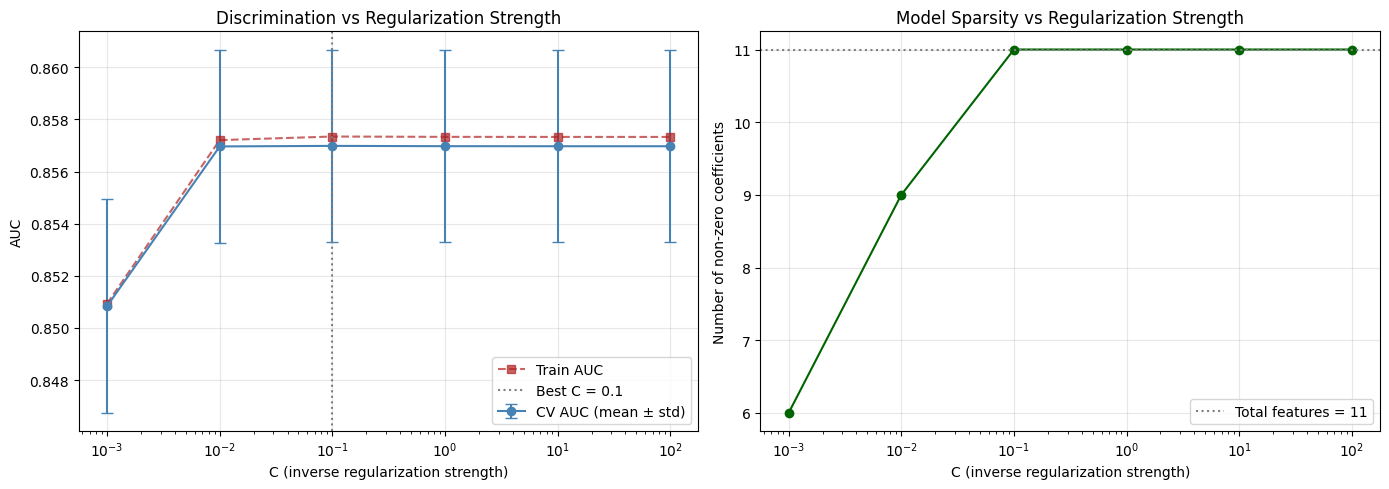

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: CV AUC vs C with error bars and train AUC overlay
ax1 = axes[0]
ax1.errorbar(
    cv_results['C'], cv_results['mean_cv_auc'],
    yerr=cv_results['std_cv_auc'],
    marker='o', capsize=4, label='CV AUC (mean ± std)', color='steelblue'
)
ax1.plot(
    cv_results['C'], cv_results['mean_train_auc'],
    marker='s', linestyle='--', label='Train AUC', color='firebrick', alpha=0.7
)
ax1.axvline(
    grid_search.best_params_['C'], color='gray', linestyle=':',
    label=f"Best C = {grid_search.best_params_['C']}"
)
ax1.set_xscale('log')
ax1.set_xlabel('C (inverse regularization strength)')
ax1.set_ylabel('AUC')
ax1.set_title('Discrimination vs Regularization Strength')
ax1.legend()
ax1.grid(alpha=0.3)

# Panel 2: Sparsity vs C
ax2 = axes[1]
ax2.plot(
    cv_results['C'], cv_results['n_nonzero_coefs'],
    marker='o', color='darkgreen'
)
ax2.axhline(
    X_train_woe.shape[1], color='gray', linestyle=':',
    label=f'Total features = {X_train_woe.shape[1]}'
)
ax2.set_xscale('log')
ax2.set_xlabel('C (inverse regularization strength)')
ax2.set_ylabel('Number of non-zero coefficients')
ax2.set_title('Model Sparsity vs Regularization Strength')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/03_lr_tuning.png', dpi=120, bbox_inches='tight')
plt.show()

**Reading the tuning curve.**

**Reading the tuning curve.** The CV AUC plateaus at C=0.01 and remains constant to four decimal places through C=100. The CV-Train gap is below 0.001 across the entire grid, confirming that overfitting is not a binding constraint — the L1 penalty is not even active at C ≥ 0.1, where all 11 coefficients reach their unpenalized maximum likelihood values. The grid search nominally selects C=0.1, but this is noise: the difference from C=0.01 is 2×10⁻⁵, far below the cross-validation standard error.

**Applying the 1-SE rule.** With std ≈ 0.0037 and K=5, the standard error of the mean CV AUC is approximately 0.0017. Any value of C with CV AUC ≥ 0.8553 is statistically indistinguishable from the maximum. C=0.01 meets this criterion with a sparser model: 9 non-zero coefficients versus 11. We select **C=0.01** as the final regularization strength on parsimony grounds.

**Headroom assessment.** No improvement in AUC was achieved by relaxing the penalty beyond C=0.01. Logistic regression on this WoE feature set has been pushed to its discriminative limit at AUC ≈ 0.857. Any further gain must come from a more flexible model class — which is exactly the question Section 7 addresses with the XGBoost challenger.


## 5. Final Model Fitting and Coefficient Inspection

We refit logistic regression at the selected `C=0.01` and examine the resulting coefficient vector $\hat{\beta} \in \mathbb{R}^{11}$. Two diagnostics matter:

**1. Which coefficients are exactly zero.** L1 regularization performs implicit feature selection. A coefficient $\hat{\beta}_j = 0$ means the data does not justify carrying feature $j$ given the penalty cost — the marginal AUC contribution from including it is smaller than the marginal penalty $\lambda |\beta_j|$. These features are dropped from the final scorecard.

**2. Whether the surviving coefficients have the right sign.** In a WoE-encoded model with the convention WoE = ln(good_rate / bad_rate), higher WoE means lower risk. We are modeling P(default), so all coefficients should be **positive**: higher WoE multiplied by a positive β increases the log-odds of being a good customer, which under our sign convention means the score correctly increases with low risk. A negative or near-zero coefficient on a surviving feature is a red flag for multicollinearity, a binning issue, or an unstable feature.

> Note on sign convention: WoE sign depends on which class is the numerator. Some scorecards use ln(bad/good); in that case all coefficients should be negative. We verify the convention from Notebook 02 below.

In [8]:
# Refit at the 1-SE rule choice
model_lr_final = LogisticRegression(
    penalty='l1',
    C=0.01,
    solver='saga',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)
model_lr_final.fit(X_train_woe, y_train)

# Extract coefficients into a tidy frame
coef_df = pd.DataFrame({
    'feature': X_train_woe.columns,
    'coefficient': model_lr_final.coef_[0],
})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df['is_zero'] = coef_df['coefficient'] == 0
coef_df = coef_df.sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

print(f"Intercept (β₀): {model_lr_final.intercept_[0]:.4f}\n")
print("Coefficient table (sorted by absolute magnitude):\n")
print(coef_df.to_string(index=False))

# Summary counts
n_total = len(coef_df)
n_dropped = coef_df['is_zero'].sum()
n_retained = n_total - n_dropped

print(f"\nFeatures retained: {n_retained} / {n_total}")
print(f"Features dropped by L1: {n_dropped}")

if n_dropped > 0:
    print("\nDropped features:")
    for f in coef_df.loc[coef_df['is_zero'], 'feature']:
        print(f"  • {f}")

Intercept (β₀): 0.0175

Coefficient table (sorted by absolute magnitude):

                             feature  coefficient  abs_coefficient  is_zero
                     DebtRatio_valid    -0.900397         0.900397    False
        NumberRealEstateLoansOrLines    -0.656029         0.656029    False
RevolvingUtilizationOfUnsecuredLines    -0.654805         0.654805    False
NumberOfTime30-59DaysPastDueNotWorse    -0.626058         0.626058    False
                   Ever90DaysPastDue    -0.611904         0.611904    False
                Ever60_89DaysPastDue    -0.529462         0.529462    False
                                 age    -0.470716         0.470716    False
     NumberOfOpenCreditLinesAndLoans    -0.156367         0.156367    False
                       MonthlyIncome    -0.043943         0.043943    False
                  NumberOfDependents     0.000000         0.000000     True
                      Income_missing     0.000000         0.000000     True

Features ret

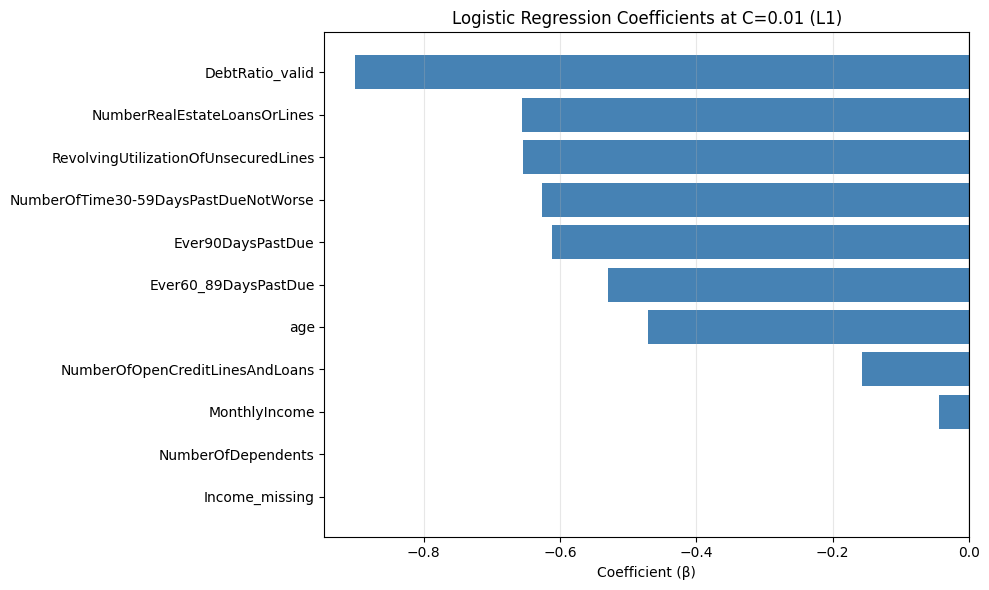

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['gray' if z else 'steelblue' for z in coef_df['is_zero']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (β)')
ax.set_title('Logistic Regression Coefficients at C=0.01 (L1)'
             )
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/03_lr_coefficients.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretation of the coefficient table.**

All nine surviving coefficients are negative, which is the correct sign pattern given the WoE convention used in Notebook 02. Under WoE = ln(non-event / event), higher WoE corresponds to safer borrowers. To produce a higher predicted P(default) for riskier borrowers (lower WoE), the linear coefficients must be negative — so that β × WoE increases as WoE decreases. The uniform sign confirms internal consistency: every feature contributes to risk in the economically expected direction. The scorecard points transformation `points = -β × WoE × (PDO / ln 2)` restores the intuitive convention where higher points = lower risk via the leading negative sign.

**L1 feature selection.** Two features were zeroed: `NumberOfDependents` (IV = 0.034) and `Income_missing` (IV = 0.012). These are the two lowest-IV features in our set. The agreement between L1's multivariate selection and IV's univariate ranking is a useful triangulation — two independent criteria identifying the same weak features strengthens the case that they are non-informative rather than misranked.

**Magnitude versus IV.** Coefficient magnitudes do not mirror IV ranking exactly. DebtRatio_valid has the largest |β| (0.90) despite a weak IV (0.081), while RevolvingUtilization — the strongest univariate predictor (IV = 1.11) — has |β| = 0.65. This is expected: IV measures standalone discriminative power, while β measures marginal contribution given the other features. RevolvingUtilization shares signal with the delinquency features (correlated information), reducing its incremental contribution. DebtRatio_valid carries information orthogonal to the delinquency block, giving it higher marginal weight. This distinction is fundamental to multivariate model interpretation.

**Final scorecard structure.** Nine features, all delinquency, utilization, debt-burden, age, and credit-line variables. Two demographic-adjacent features (dependents, income-missing flag) were removed. The resulting model is more parsimonious and easier to monitor in production.

## 6. Calibration Correction for the Class-Balancing Prior Shift

The model fit in Section 5 used `class_weight='balanced'`, which reweights each observation so that the two classes contribute equally to the loss function. This was the right choice for **discrimination** — the AUC of 0.857 reflects rank-ordering ability uncontaminated by class imbalance. It is the wrong choice for **calibration** — the predicted probabilities are systematically inflated, and uncorrected they would propagate into ECL provisions that are nearly an order of magnitude too high.

This section derives the log-odds correction that restores calibration, applies it to train and test predictions, and verifies the result visually and numerically.

### Why the correction is needed

Class weighting is mathematically equivalent to oversampling the minority class to a 50/50 prior. The model does not know the true population prior is 6.68%; it learns the conditional structure $P(\text{features} \mid \text{class})$ but anchors its outputs to a 50% base rate. The resulting probabilities answer the question "given that defaulters and non-defaulters are equally common, what is the probability this applicant defaults?" — which is not the question we need answered for IFRS 9.

For IFRS 9 ECL, the formula is:

$$\text{ECL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

A miscalibrated PD scales the entire provision linearly. If raw model outputs average 50% but the true default rate is 6.68%, ECL would be inflated by a factor of approximately $0.50 / 0.0668 \approx 7.5$. This is a regulatory and accounting failure of the first order.

### The correction, derived

Let $\pi_{\text{train}} = 0.5$ be the effective prior the model trained against (due to class balancing) and $\pi_{\text{true}} = 0.0668$ be the true population prior. Bayes' rule gives us a way to convert.

Under the training prior, the model outputs:

$$P_{\text{train}}(y=1 \mid x) = \frac{P(x \mid y=1) \pi_{\text{train}}}{P(x \mid y=1) \pi_{\text{train}} + P(x \mid y=0)(1-\pi_{\text{train}})}$$

Under the true prior, we want:

$$P_{\text{true}}(y=1 \mid x) = \frac{P(x \mid y=1) \pi_{\text{true}}}{P(x \mid y=1) \pi_{\text{true}} + P(x \mid y=0)(1-\pi_{\text{true}})}$$

The key insight: the likelihood ratio $P(x \mid y=1) / P(x \mid y=0)$ is invariant to the prior — it is a property of the data, not the sampling scheme. We can extract it from the model's output.

Taking the log-odds of $P_{\text{train}}$:

$$\text{logit}(P_{\text{train}}) = \ln \frac{P(x \mid y=1)}{P(x \mid y=0)} + \ln \frac{\pi_{\text{train}}}{1-\pi_{\text{train}}}$$

And of $P_{\text{true}}$:

$$\text{logit}(P_{\text{true}}) = \ln \frac{P(x \mid y=1)}{P(x \mid y=0)} + \ln \frac{\pi_{\text{true}}}{1-\pi_{\text{true}}}$$

Subtracting:

$$\text{logit}(P_{\text{true}}) = \text{logit}(P_{\text{train}}) + \ln \frac{\pi_{\text{true}}}{1-\pi_{\text{true}}} - \ln \frac{\pi_{\text{train}}}{1-\pi_{\text{train}}}$$

This is the correction. In code: convert raw predictions to log-odds, add the constant offset $\ln(\pi_{\text{true}}/(1-\pi_{\text{true}})) - \ln(\pi_{\text{train}}/(1-\pi_{\text{train}}))$, convert back to probability via the sigmoid.

For our values: $\ln(0.0668/0.9332) - \ln(0.5/0.5) = \ln(0.0716) - 0 = -2.637$. Every predicted log-odds is shifted down by 2.637, which corresponds to dividing the odds ratio by $e^{2.637} \approx 13.97$.

### Properties of the correction

Two properties make this correction clean:

**1. AUC is preserved exactly.** The correction is a monotonic transformation (constant shift in log-odds, equivalent to a monotonic rescaling of probability). AUC depends only on the rank-ordering of scores, which a monotonic transform cannot change. Our 0.857 AUC survives the correction unchanged.

**2. Calibration is restored without retraining.** No new optimization, no held-out calibration set, no Platt scaling or isotonic regression. The correction is a closed-form scalar adjustment derived from Bayes' rule. This is why it is preferred over post-hoc calibration methods for the specific case of correcting a known prior shift.